# 14 — EDA fase 5: clima y casos

**Pregunta guía:** ¿qué variables climáticas, y con qué rezago, se asocian con los casos de forma estable?

Dataset: `data/silver/integrado/meteo_socio_epi_piura_2017_2025.csv` (solo lectura). Rezagos, anomalías y agregaciones se calculan **en memoria** para describir; nada se guarda en `data/` ni es una feature.

**Cómo se evita confundir clima con calendario:** clima y casos son estacionales, así que una correlación cruda es en buena parte calendario. Cada relación se mira en tres versiones:
1. **bruta**: los valores tal cual;
2. **anomalía**: cada serie menos su climatología por distrito × semana epidemiológica, calculada con todos los años (descriptiva);
3. **intra-temporada**: la anomalía menos, además, la media del distrito en esa temporada. Así se quita también la diferencia entre años, y queda solo si, *dentro* de una temporada, las semanas más húmedas o cálidas preceden semanas con más casos.

**Supuestos de trabajo:**
- Distritos activos (≥ 20 % de semanas con casos, n = 31, fase 3), porque en los demás casi no hay variación de casos.
- `lluvia_total_mm` se omite porque es idéntica a `precip_total_mm` (fase 1).
- Temporadas de la semana 35 a la 34.
- Como en las fases anteriores, 2025 va incluido pero marcado aparte, y "costa/sierra" se aproxima por provincia.

Etiquetas: **Observación** · **Hipótesis** · **Implicación**.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

from src.eda.carga import cargar_integrado, OBJETIVO
from src.eda.clima import (anomalia, rezagar, correlacion_rezagada, bootstrap_bloques,
                           correlacion_parcial_spearman, centro_estacional)
from src.eda.objetivo import brote_umbral_tasa, marcar_arranque, sin_marca_previa
from src.eda.temporal import asignar_temporada
from src.eda.estilo import aplicar_estilo, guardar_figura, guardar_metricas, COLORES

aplicar_estilo()
FASE = "fase5_clima"
H, REZAGOS, SEMANA_CORTE = 4, range(0, 13), 35
SIERRA = ["Ayabaca", "Huancabamba"]
VARS = ["temp_media", "temp_max", "temp_min", "precip_total_mm", "hum_rel_media", "viento_max", "radiacion_total", "et0_total"]
ETIQ = {"temp_media": "Temperatura media (°C)", "temp_max": "Temperatura máxima semanal (°C)", "temp_min": "Temperatura mínima semanal (°C)",
        "precip_total_mm": "Precipitación (mm/semana)", "hum_rel_media": "Humedad relativa media (%)",
        "viento_max": "Viento máximo (km/h)", "radiacion_total": "Radiación (MJ/m²/semana)", "et0_total": "ET0 (mm/semana)"}
M = {"horizonte_semanas": H, "variables": VARS}

df = cargar_integrado()
df["l"] = np.log1p(df[OBJETIVO])                                               # en memoria
df["temporada"] = asignar_temporada(df["anio"], df["semana"], SEMANA_CORTE)
activos = df.groupby("ubigeo")[OBJETIVO].apply(lambda s: (s > 0).mean() >= 0.2)
activos = list(activos[activos].index)
d = df[df["ubigeo"].isin(activos)].copy()
d["l_an"] = anomalia(d, "l")
d["l_it"] = d["l_an"] - d.groupby(["ubigeo", "temporada"])["l_an"].transform("mean")
for v in VARS:
    d[f"{v}_an"] = anomalia(d, v)
    d[f"{v}_it"] = d[f"{v}_an"] - d.groupby(["ubigeo", "temporada"])[f"{v}_an"].transform("mean")
M["n_distritos_activos"] = len(activos)
print(d.shape, "| distritos activos:", len(activos))

(14539, 55) | distritos activos: 31


## 1. Estacionalidad del clima y diferencias costa / sierra

**Qué quiero saber:** el ciclo anual típico de cada variable (mediana por semana epidemiológica) en la costa y en la sierra, y cuánto difieren los niveles. Si el clima tiene la misma estacionalidad que los casos, las correlaciones crudas estarán infladas por el calendario.

Centro estacional (semana) en la costa: {'temp_media': 9.2, 'temp_min': 9.6, 'precip_total_mm': 9.5, 'hum_rel_media': 30.0} | casos: 18.6
Semana del pico regional por año: {2017: 18, 2018: 15, 2019: 22, 2020: 10, 2021: 20, 2022: 16, 2023: 20, 2024: 14, 2025: 4}
Media por zona: {'temp_media': {'Costa (otras 6 provincias)': 22.8, 'Sierra (Ayabaca, Huancabamba)': 17.1}, 'temp_max': {'Costa (otras 6 provincias)': 30.6, 'Sierra (Ayabaca, Huancabamba)': 23.3}, 'temp_min': {'Costa (otras 6 provincias)': 17.8, 'Sierra (Ayabaca, Huancabamba)': 12.3}, 'precip_total_mm': {'Costa (otras 6 provincias)': 10.7, 'Sierra (Ayabaca, Huancabamba)': 36.7}, 'hum_rel_media': {'Costa (otras 6 provincias)': 70.0, 'Sierra (Ayabaca, Huancabamba)': 80.5}, 'viento_max': {'Costa (otras 6 provincias)': 22.7, 'Sierra (Ayabaca, Huancabamba)': 13.1}, 'radiacion_total': {'Costa (otras 6 provincias)': 149.8, 'Sierra (Ayabaca, Huancabamba)': 136.4}, 'et0_total': {'Costa (otras 6 provincias)': 33.4, 'Sierra (Ayabaca, Huanc

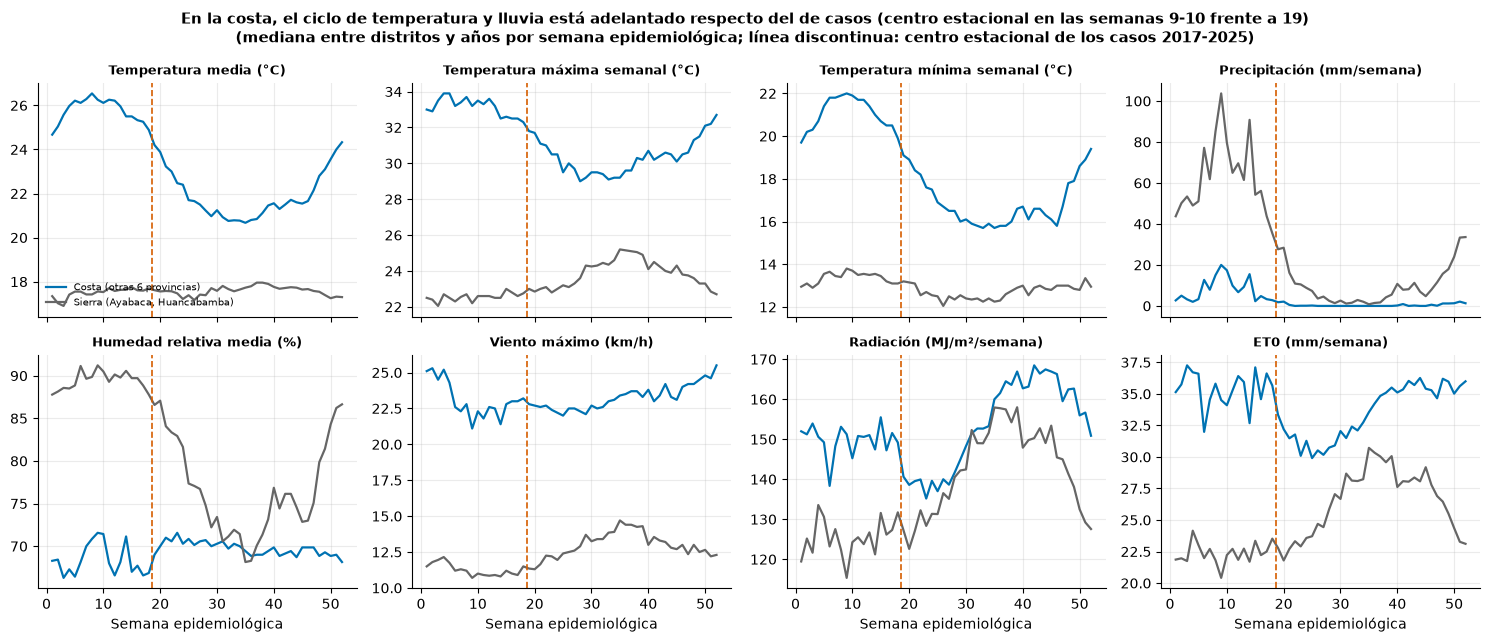

In [2]:
df["zona"] = np.where(df["provincia"].isin(SIERRA), "Sierra (Ayabaca, Huancabamba)", "Costa (otras 6 provincias)")
clim = df.assign(sem=df["semana"].clip(upper=52)).groupby(["zona", "sem"])[VARS].median()
M["media_por_zona"] = {v: {z: round(float(df.loc[df["zona"] == z, v].mean()), 1) for z in df["zona"].unique()} for v in VARS}
casos_sem = df.assign(sem=df["semana"].clip(upper=52)).groupby("sem")[OBJETIVO].sum()
# Semana de máximo de la climatología costera de cada variable
M["semana_maximo_climatologia_costa"] = {v: int(clim.loc["Costa (otras 6 provincias)", v].idxmax()) for v in VARS}
M["semana_maximo_casos_totales"] = int(casos_sem.idxmax())
# Centro de masa circular del ciclo (costa): más estable que un pico puntual. Para el clima se usa el perfil menos su mínimo.
costa_clim = clim.loc["Costa (otras 6 provincias)"]
M["centro_estacional_semana_costa"] = {v: round(centro_estacional(costa_clim[v] - costa_clim[v].min()), 1) for v in ["temp_media", "temp_min", "precip_total_mm", "hum_rel_media"]}
M["centro_estacional_semana_casos"] = round(centro_estacional(casos_sem), 1)
picos_anio = df.groupby(["anio", "semana"])[OBJETIVO].sum().groupby("anio").idxmax().map(lambda t: t[1])
M["semana_pico_regional_por_anio"] = {int(a): int(s_) for a, s_ in picos_anio.items()}
M["rango_temp_media_climatologia_costa_sem_4_13"] = [round(float(costa_clim.loc[4:13, "temp_media"].min()), 1), round(float(costa_clim.loc[4:13, "temp_media"].max()), 1)]
print("Centro estacional (semana) en la costa:", M["centro_estacional_semana_costa"], "| casos:", M["centro_estacional_semana_casos"])
print("Semana del pico regional por año:", M["semana_pico_regional_por_anio"])
print("Media por zona:", M["media_por_zona"])
print("Semana del máximo climatológico en la costa:", M["semana_maximo_climatologia_costa"], "| semana con más casos (suma 2017-2025):", M["semana_maximo_casos_totales"])

fig, axes = plt.subplots(2, 4, figsize=(15, 6.5), sharex=True)
for ax, v in zip(axes.flat, VARS):
    for z, color in [("Costa (otras 6 provincias)", COLORES["clima"]), ("Sierra (Ayabaca, Huancabamba)", COLORES["referencia"])]:
        ax.plot(clim.loc[z].index, clim.loc[z, v], color=color, lw=1.6, label=z)
    ax.axvline(M["centro_estacional_semana_casos"], color=COLORES["casos"], lw=1.2, ls="--")
    ax.set_title(ETIQ[v], fontsize=9)
for ax in axes[1]:
    ax.set_xlabel("Semana epidemiológica")
axes[0, 0].legend(loc="lower left", fontsize=7)
centros = [M["centro_estacional_semana_costa"][v] for v in ["temp_media", "temp_min", "precip_total_mm"]]
fig.suptitle(f"En la costa, el ciclo de temperatura y lluvia está adelantado respecto del de casos (centro estacional en las semanas {min(centros):.0f}-{max(centros):.0f} frente a {M['centro_estacional_semana_casos']:.0f})\n(mediana entre distritos y años por semana epidemiológica; línea discontinua: centro estacional de los casos 2017-2025)",
             fontweight="bold", fontsize=11)
fig.tight_layout()
guardar_figura(fig, FASE, "01_estacionalidad_clima")
plt.show()

**Observación.** En la costa, la temperatura y la precipitación tienen un ciclo anual marcado cuya **fase está adelantada** unas 9-10 semanas respecto del ciclo de casos (centros estacionales arriba). Algunas precisiones:
- En un ciclo anual, "adelantado" describe un desfase de fase, no un orden causal.
- La temperatura media costera forma una meseta entre las semanas 4 y 13, así que su "pico" puntual no está bien definido.
- El ciclo de casos está dominado por 2023; el pico regional varía mucho entre años (lista arriba).
- La humedad costera varía poco a lo largo del año. La sierra es varios grados más fría, llueve mucho más y tiene otro ciclo.
**Implicación.**
- Cualquier correlación clima-casos sin quitar la estacionalidad mezcla calendario con clima (sección 3).
- Como las zonas difieren tanto en nivel, relacionar valores crudos de clima con casos entre distritos confunde "zona" con "clima". Por eso lo relevante es la variación **dentro** de cada distrito.

## 2. Redundancia entre variables climáticas

**Qué quiero saber:** qué variables aportan información distinta. Se mide con Spearman (a) en bruto, sobre todas las filas (mezcla distritos y estaciones), y (b) entre anomalías dentro de cada distrito (mediana entre distritos activos), que es la variación relevante para un modelo que ya conoce el distrito y la semana.

Pares con |rho| ≥ 0.8 (bruta o anomalía dentro de distrito):
   temp_media ~ temp_max {'bruta': 0.93, 'anomalia_dentro': 0.75}
   temp_media ~ temp_min {'bruta': 0.95, 'anomalia_dentro': 0.75}
   temp_max ~ temp_min {'bruta': 0.82, 'anomalia_dentro': 0.33}
   hum_rel_media ~ et0_total {'bruta': -0.8, 'anomalia_dentro': -0.81}
   radiacion_total ~ et0_total {'bruta': 0.79, 'anomalia_dentro': 0.82}


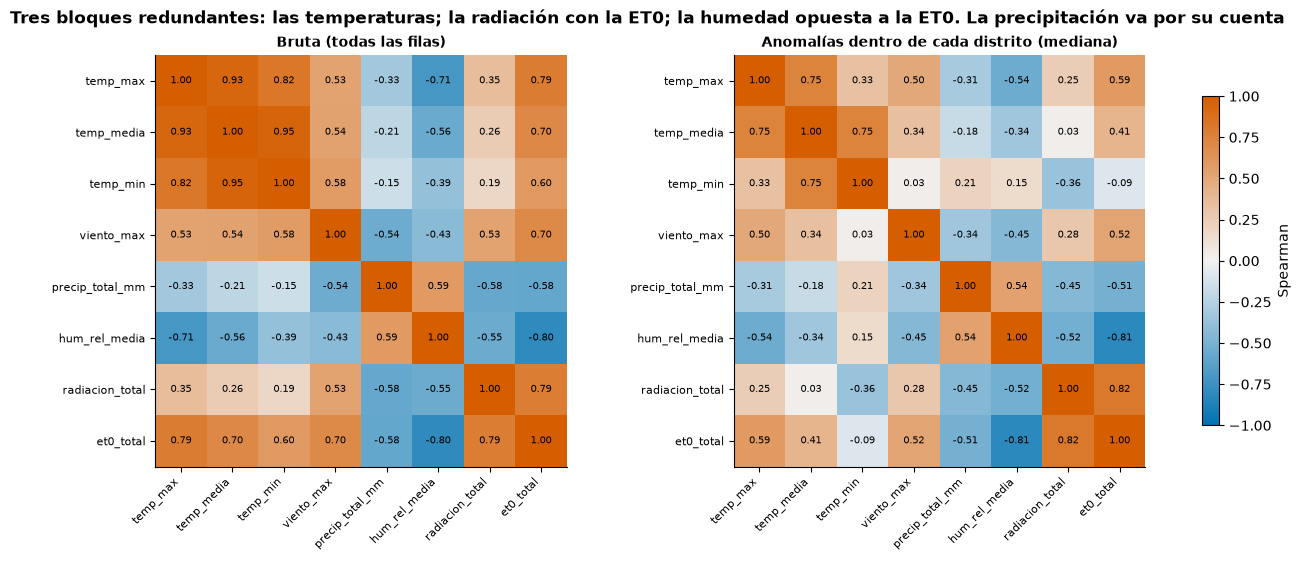

In [3]:
bruta = df[VARS].corr(method="spearman")
cols_an = [f"{v}_an" for v in VARS]
dentro = pd.concat([g[cols_an].corr(method="spearman") for _, g in d.groupby("ubigeo")]).groupby(level=0).median()
dentro = dentro.loc[cols_an, cols_an]            # groupby ordena las filas alfabéticamente: se realinean con las columnas
dentro.columns = dentro.index = VARS
iu = np.triu_indices(len(VARS), 1)
pares = [(VARS[i], VARS[j], round(float(bruta.iloc[i, j]), 2), round(float(dentro.iloc[i, j]), 2)) for i, j in zip(*iu)]
M["pares_redundantes_abs_rho_ge_0_8"] = {f"{a} ~ {b}": {"bruta": r1, "anomalia_dentro": r2} for a, b, r1, r2 in pares if max(abs(r1), abs(r2)) >= 0.8}
print("Pares con |rho| ≥ 0.8 (bruta o anomalía dentro de distrito):")
for k, v in M["pares_redundantes_abs_rho_ge_0_8"].items():
    print("  ", k, v)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), layout="constrained")
cmap = LinearSegmentedColormap.from_list("div", [COLORES["clima"], "#f2f2f2", COLORES["casos"]])
orden = [VARS[i] for i in leaves_list(linkage(squareform(1 - dentro.abs().to_numpy(), checks=False), "average"))]
for ax, mat, tit in [(axes[0], bruta, "Bruta (todas las filas)"), (axes[1], dentro, "Anomalías dentro de cada distrito (mediana)")]:
    m = mat.loc[orden, orden]
    im = ax.imshow(m.to_numpy(), cmap=cmap, vmin=-1, vmax=1)
    ax.set_xticks(range(len(orden)), orden, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(orden)), orden, fontsize=8)
    for i in range(len(orden)):
        for j in range(len(orden)):
            ax.text(j, i, f"{m.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
    ax.grid(False)
    ax.set_title(tit, fontsize=10)
fig.colorbar(im, ax=axes, shrink=0.8, label="Spearman")
fig.suptitle("Tres bloques redundantes: las temperaturas; la radiación con la ET0; la humedad opuesta a la ET0. La precipitación va por su cuenta", fontweight="bold")
guardar_figura(fig, FASE, "02_redundancia_clima")
plt.show()

**Observación** (pares con |rho| ≥ 0.8 listados arriba):
- **Temperaturas:** forman un bloque. En bruto están muy correlacionadas; como anomalías dentro del distrito, la media sigue muy ligada a la máxima y a la mínima, pero la máxima y la mínima se separan bastante.
- **Radiación y ET0:** van juntas.
- **Humedad y ET0:** son casi opuestas, en bruto y en anomalías.
- **Precipitación:** no forma pares fuertes con ninguna otra variable.
**Implicación.**
- Basta con un representante por bloque. Candidatas según las secciones siguientes: humedad (que además resume a la ET0), precipitación y, con cautela, una temperatura (la mínima, que es la menos ligada a la máxima). Radiación y ET0 serían redundantes con la humedad.
- Usar todas las variables sin selección añade colinealidad sin información nueva. Recomendación para feature engineering.

## 3. Correlación cruzada clima → casos, rezagos 0-12 semanas

**Qué quiero saber:** la correlación de Spearman entre `log1p(casos)` en t y cada variable climática en t − rezago, en las tres versiones (bruta, anomalía, intra-temporada). Se calcula a nivel **regional** (suma de casos y media de clima de los distritos activos) y **dentro de cada distrito** (mediana entre los 31 activos). También se calcula por provincia (anomalías, mediana distrital). Solo las correlaciones en rezagos ≥ 4 serían utilizables a horizonte 4.

In [4]:
reg = d.groupby("semana_inicio").agg(casos=(OBJETIVO, "sum"), semana=("semana", "first"), temporada=("temporada", "first"),
                                     **{v: (v, "mean") for v in VARS}).reset_index()
reg["ubigeo"] = "REGION"
reg["l"] = np.log1p(reg["casos"])
reg["l_an"] = anomalia(reg, "l")
for v in VARS:
    reg[f"{v}_an"] = anomalia(reg, v)

ccf = {}
for v in VARS:
    ccf[(v, "regional_bruta")] = correlacion_rezagada(reg, v, "l", REZAGOS, grupo=None).iloc[0]
    ccf[(v, "regional_anomalia")] = correlacion_rezagada(reg, f"{v}_an", "l_an", REZAGOS, grupo=None).iloc[0]
    ccf[(v, "distrital_bruta")] = correlacion_rezagada(d, v, "l", REZAGOS).median()
    ccf[(v, "distrital_anomalia")] = correlacion_rezagada(d, f"{v}_an", "l_an", REZAGOS).median()
    ccf[(v, "distrital_intra_temporada")] = correlacion_rezagada(d, f"{v}_it", "l_it", REZAGOS).median()
ccf = pd.DataFrame(ccf).T
ccf.index.names = ["variable", "version"]

def mejor(serie, desde=0):
    s = serie.loc[desde:]
    r = int(s.abs().idxmax())
    return {"rezago": r, "rho": round(float(s[r]), 3)}

M["ccf"] = {v: {ver: {int(k): round(float(x), 3) for k, x in ccf.loc[(v, ver)].items()} for ver in ccf.loc[v].index} for v in VARS}
M["mejor_rezago_ge_4"] = {v: {ver: mejor(ccf.loc[(v, ver)], desde=H) for ver in ccf.loc[v].index} for v in VARS}
resumen = pd.DataFrame({v: {ver: f"{x['rho']:+.2f} (r{x['rezago']})" for ver, x in M["mejor_rezago_ge_4"][v].items()} for v in VARS}).T
resumen

,regional_bruta,regional_anomalia,distrital_bruta,distrital_anomalia,distrital_intra_temporada
temp_media,+0.33 (r7),+0.03 (r5),+0.33 (r8),+0.02 (r4),+0.05 (r4)
temp_max,+0.27 (r10),+0.04 (r12),+0.23 (r10),-0.02 (r4),-0.08 (r7)
temp_min,+0.36 (r7),+0.19 (r4),+0.37 (r8),+0.17 (r5),+0.15 (r4)
precip_total_mm,+0.28 (r9),+0.18 (r12),+0.24 (r8),+0.24 (r9),+0.17 (r8)
hum_rel_media,+0.16 (r4),+0.24 (r4),+0.14 (r5),+0.26 (r7),+0.29 (r7)
viento_max,-0.10 (r4),-0.10 (r10),-0.14 (r4),-0.14 (r7),-0.17 (r5)
radiacion_total,-0.17 (r4),-0.11 (r4),-0.16 (r4),-0.11 (r4),-0.12 (r4)
et0_total,-0.07 (r4),-0.11 (r4),-0.10 (r4),-0.13 (r4),-0.17 (r4)


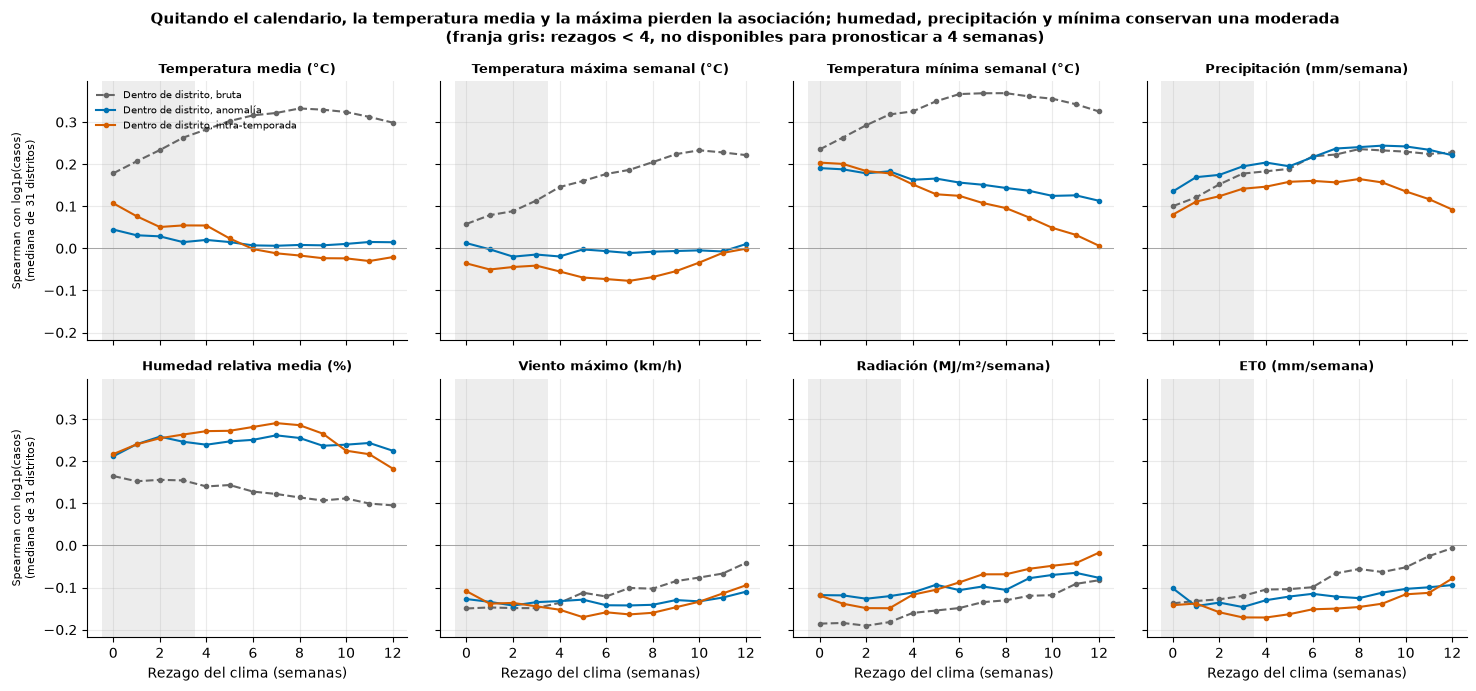

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(15, 7), sharex=True, sharey=True)
estilos = [("distrital_bruta", COLORES["referencia"], "--", "Dentro de distrito, bruta"),
           ("distrital_anomalia", COLORES["clima"], "-", "Dentro de distrito, anomalía"),
           ("distrital_intra_temporada", COLORES["casos"], "-", "Dentro de distrito, intra-temporada")]
for ax, v in zip(axes.flat, VARS):
    for ver, color, ls, lab in estilos:
        ax.plot(list(REZAGOS), ccf.loc[(v, ver)].to_numpy(), color=color, ls=ls, marker="o", ms=3, lw=1.5, label=lab)
    ax.axhline(0, color="#999999", lw=0.6)
    ax.axvspan(-0.5, H - 0.5, color="#dddddd", alpha=0.5, lw=0)
    ax.set_title(ETIQ[v], fontsize=9)
for ax in axes[1]:
    ax.set_xlabel("Rezago del clima (semanas)")
for ax in axes[:, 0]:
    ax.set_ylabel("Spearman con log1p(casos)\n(mediana de 31 distritos)", fontsize=8)
axes[0, 0].legend(loc="upper left", fontsize=7)
fig.suptitle(f"Quitando el calendario, la temperatura media y la máxima pierden la asociación; humedad, precipitación y mínima conservan una moderada\n(franja gris: rezagos < {H}, no disponibles para pronosticar a {H} semanas)",
             fontweight="bold", fontsize=11)
fig.tight_layout()
guardar_figura(fig, FASE, "03_correlacion_cruzada")
plt.show()

In [6]:
# Por provincia (anomalías, mediana distrital) en el rezago 6 como referencia intermedia de la ventana 4-8
d_prov = d.assign(prov=d["provincia"])
tabla_prov = {}
for v in ["temp_min", "precip_total_mm", "hum_rel_media"]:
    for p, g in d_prov.groupby("prov"):
        c = correlacion_rezagada(g, f"{v}_an", "l_an", [6])
        tabla_prov[(v, p)] = {"n_distritos": int(g["ubigeo"].nunique()), "rho_mediana_r6": round(float(c[6].median()), 3)}
tabla_prov = pd.DataFrame(tabla_prov).T
M["anomalia_r6_por_provincia"] = {f"{v} | {p}": {k: (int(x) if k == "n_distritos" else float(x)) for k, x in f.items()} for (v, p), f in tabla_prov.iterrows()}
tabla_prov.unstack(0)

n_distritos                          rho_mediana_r6  \
         hum_rel_media precip_total_mm temp_min  hum_rel_media   
Morropón           6.0             6.0      6.0          0.096   
Paita              2.0             2.0      2.0          0.191   
Piura              9.0             9.0      9.0          0.254   
Sechura            3.0             3.0      3.0          0.169   
Sullana            7.0             7.0      7.0          0.327   
Talara             4.0             4.0      4.0          0.358   

                                   
         precip_total_mm temp_min  
Morropón           0.175    0.067  
Paita              0.168    0.129  
Piura              0.217    0.164  
Sechura            0.182    0.187  
Sullana            0.264    0.166  
Talara             0.279    0.125

**Observación.** La tabla muestra, para cada versión, el rezago ≥ 4 de mayor |rho|; ese rezago puede ser distinto en cada versión, y la figura muestra las curvas completas.
- **Temperatura media y máxima:** la correlación cruda con los casos es positiva y crece con el rezago, pero al quitar la estacionalidad **desaparece** en todos los rezagos. Esa asociación era casi todo calendario.
- **Temperatura mínima, precipitación y humedad:** mantienen una correlación positiva, moderada, en anomalía y también intra-temporada. En la humedad es la más estable a lo largo de los rezagos; en la temperatura mínima disminuye con el rezago, y la sección 6 muestra que no es robusta.
- **Viento, radiación y ET0:** su correlación es negativa y débil.
- Las curvas son bastante planas entre los rezagos 4 y 12. La serie de clima tiene autocorrelación alta, así que el "mejor rezago" está mal identificado: la tabla lo informa, pero con cautela.
- Por provincia el signo se repite en las provincias con casos, con magnitudes distintas (tabla).

**Hipótesis.** Condiciones más húmedas y noches más cálidas favorecerían la transmisión con semanas de retraso (conocimiento general del mecanismo, no verificado aquí).
**Implicación.** Variables candidatas: `hum_rel_media` y `precip_total_mm` (y `temp_min` con cautela, ver sección 6), expresadas como **anomalías** respecto de una climatología calculada solo con entrenamiento y agregadas en una **ventana** de rezagos (por ejemplo, 4-8 semanas) en lugar de un rezago único, porque el rezago puntual no está bien identificado. `temp_media` y `temp_max` aportarían sobre todo calendario, que el modelo ya recibe por la semana epidemiológica.

## 4. ¿El clima aporta más allá de la persistencia?

La fase 3 mostró que repetir el valor de t − 4 ya es una línea base fuerte. Lo que un pronóstico necesita del clima es información sobre el **cambio** entre t − 4 y t. Por eso se correlaciona la anomalía climática en t − rezago (rezago ≥ 4) con Δ = log1p(casos_t) − log1p(casos_{t−4}), dentro de cada distrito activo (mediana).

In [7]:
d["delta4"] = d["l"] - rezagar(d, "l", H)
aporte = {v: correlacion_rezagada(d, f"{v}_an", "delta4", range(H, 13)).median() for v in VARS}
aporte = pd.DataFrame(aporte).T
M["corr_anomalia_con_cambio_4_semanas"] = {v: {int(k): round(float(x), 3) for k, x in fila.items()} for v, fila in aporte.iterrows()}
M["corr_cambio_max_abs_por_variable"] = {v: round(float(fila.loc[fila.abs().idxmax()]), 3) for v, fila in aporte.iterrows()}
M["corr_cambio_rezago_del_maximo"] = {v: int(fila.abs().idxmax()) for v, fila in aporte.iterrows()}
# Correlación parcial: anomalía climática media de los rezagos 4-8 vs anomalía de casos en t, controlando por la anomalía de casos en t - 4
d["l_an_t4"] = rezagar(d, "l_an", H)
for v in VARS:
    d[f"{v}_an_v48"] = sum(rezagar(d, f"{v}_an", r) for r in range(4, 9)) / 5
parcial = {v: float(pd.Series({u: correlacion_parcial_spearman(g[f"{v}_an_v48"], g["l_an"], g["l_an_t4"]) for u, g in d.groupby("ubigeo")}).median())
           for v in VARS}
M["corr_parcial_v48_controlando_casos_t4"] = {v: round(x, 3) for v, x in parcial.items()}
print("Correlación parcial (mediana de distritos), ventana 4-8 vs anomalía de casos | anomalía de casos en t-4:", M["corr_parcial_v48_controlando_casos_t4"])
print("Máxima |correlación| (con signo) entre anomalía rezagada (4-12) y el cambio a 4 semanas:", M["corr_cambio_max_abs_por_variable"])
aporte.round(3)

Correlación parcial (mediana de distritos), ventana 4-8 vs anomalía de casos | anomalía de casos en t-4: {'temp_media': -0.022, 'temp_max': -0.03, 'temp_min': 0.024, 'precip_total_mm': 0.161, 'hum_rel_media': 0.12, 'viento_max': -0.084, 'radiacion_total': -0.025, 'et0_total': -0.05}
Máxima |correlación| (con signo) entre anomalía rezagada (4-12) y el cambio a 4 semanas: {'temp_media': -0.054, 'temp_max': -0.047, 'temp_min': -0.074, 'precip_total_mm': 0.064, 'hum_rel_media': -0.059, 'viento_max': -0.055, 'radiacion_total': 0.061, 'et0_total': -0.055}


,4,5,6,7,8,9,10,11,12
temp_media,-0.038,-0.054,-0.046,-0.045,-0.045,-0.029,-0.020,-0.007,-0.006
temp_max,-0.047,-0.032,-0.040,-0.024,-0.014,-0.002,0.009,0.033,0.038
temp_min,-0.018,-0.027,-0.031,-0.036,-0.045,-0.050,-0.066,-0.066,-0.074
precip_total_mm,0.017,0.005,0.033,0.050,0.064,0.025,0.027,0.013,0.015
hum_rel_media,0.054,0.035,0.015,0.004,0.008,-0.016,-0.026,-0.042,-0.059
viento_max,-0.055,-0.051,-0.050,-0.046,-0.031,-0.032,-0.005,0.002,0.035
radiacion_total,-0.017,-0.000,0.008,0.004,0.029,0.011,0.034,0.039,0.061
et0_total,-0.055,-0.022,-0.012,-0.013,-0.017,-0.001,-0.000,0.017,0.042


**Observación.**
- Las correlaciones con el cambio a 4 semanas son **mucho más pequeñas** que las correlaciones con el nivel, y en algunas variables cambian de signo según el rezago (cifras arriba).
- La correlación parcial de la ventana 4-8 con los casos, **controlando por los casos en t − 4**, conserva una parte de la señal en humedad y precipitación, pero es cercana a 0 en la temperatura mínima (cifras arriba).

**Hipótesis.** Buena parte de la asociación entre clima y casos coincide con lo que ya reflejan los casos de t − 4: los años húmedos son también los años con casos altos.
**Implicación.** El clima puede aportar poco a un modelo que ya usa la historia propia del distrito, aunque la parcial sugiere que humedad y precipitación conservan algo de información propia. Habrá que medir su aporte comparando modelos con y sin clima contra la línea base de persistencia, no por su correlación con el nivel. Donde más podría aportar es en los arranques (sección 7).

## 5. Forma de la relación: umbrales y no linealidad

**Qué quiero saber:** cómo cambian los casos a lo largo de los deciles de cada variable clave en el rezago 6 (mitad de la ventana 4-8), con deciles calculados dentro de cada distrito, en tres versiones:
- **bruta**: mezcla clima con calendario;
- **anomalía**: quita el calendario, pero conserva las diferencias entre años;
- **intra-temporada**: quita calendario y año, es decir, compara semanas más o menos cálidas o húmedas **dentro de una misma temporada**.

Se revisa además si el decil superior depende de las temporadas de brote (sin 2023 y 2024).

% de las semanas del decil 10 (anomalía) que caen en las temporadas 2017, 2023 o 2024: {'temp_min': 77.4, 'precip_total_mm': 60.7, 'hum_rel_media': 66.8, 'temp_media': 73.8}


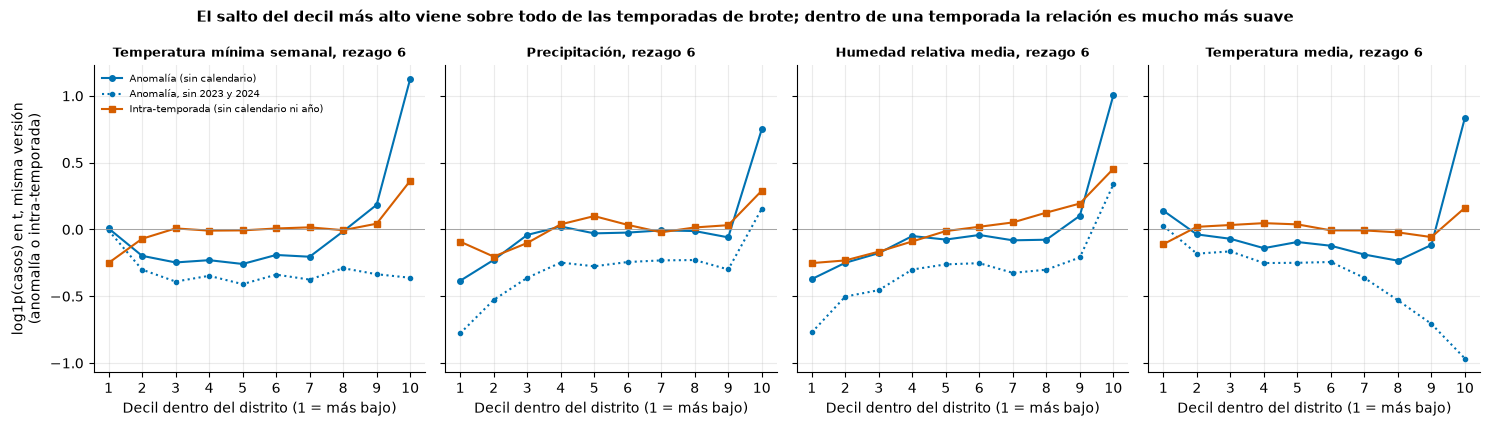

temp_min                                                  \
         bruta anomalia anomalia_sin_2023_2024 intra_temporada   
decil                                                            
1        0.296    0.007                 -0.007          -0.251   
2        0.297   -0.198                 -0.301          -0.070   
3        0.301   -0.247                 -0.390           0.008   
4        0.414   -0.230                 -0.347          -0.009   
5        0.576   -0.259                 -0.409          -0.007   
6        0.920   -0.191                 -0.338           0.007   
7        0.988   -0.204                 -0.375           0.016   
8        1.120   -0.015                 -0.290          -0.005   
9        1.510    0.184                 -0.335           0.043   
10       1.679    1.126                 -0.362           0.364   

      precip_total_mm                                                  \
                bruta anomalia anomalia_sin_2023_2024 intra_temporada   
decil                                                                   
1               0.233   -0.384                 -0.778          -0.091   
2               0.376   -0.228                 -0.528          -0.203   
3               0.814   -0.041                 -0.362          -0.101   
4               0.948    0.022                 -0.248           0.038   
5               0.578   -0.029                 -0.276           0.100   
6               0.710   -0.024                 -0.244           0.034   
7               0.784   -0.007                 -0.232          -0.021   
8               0.799   -0.012                 -0.229           0.015   
9               0.859   -0.059                 -0.300           0.032   
10              1.993    0.750                  0.155           0.290   

      hum_rel_media                                                  \
              bruta anomalia anomalia_sin_2023_2024 intra_temporada   
decil                                                                 
1             0.932   -0.372                 -0.771          -0.252   
2             0.619   -0.250                 -0.503          -0.232   
3             0.560   -0.177                 -0.454          -0.166   
4             0.661   -0.050                 -0.300          -0.090   
5             0.634   -0.076                 -0.262          -0.012   
6             0.584   -0.042                 -0.252           0.020   
7             0.567   -0.081                 -0.325           0.052   
8             0.644   -0.077                 -0.301           0.126   
9             0.770    0.102                 -0.210           0.194   
10            2.104    1.004                  0.336           0.454   

      temp_media                                                  
           bruta anomalia anomalia_sin_2023_2024 intra_temporada  
decil                                                             
1          0.298    0.140                  0.027          -0.110  
2          0.318   -0.037                 -0.181           0.020  
3          0.324   -0.070                 -0.164           0.033  
4          0.366   -0.140                 -0.252           0.047  
5          0.544   -0.094                 -0.250           0.038  
6          1.069   -0.122                 -0.244          -0.007  
7          1.443   -0.188                 -0.363          -0.007  
8          1.480   -0.234                 -0.530          -0.022  
9          1.061   -0.116                 -0.707          -0.057  
10         1.208    0.836                 -0.966           0.162

In [8]:
R = 6
CLAVE = ["temp_min", "precip_total_mm", "hum_rel_media", "temp_media"]

def deciles_dentro(x):
    return x.groupby(d["ubigeo"]).transform(lambda s: pd.qcut(s.rank(method="first"), 10, labels=False) + 1 if s.notna().sum() >= 10 else np.nan)

forma = {}
for v in CLAVE:
    x_an, x_br = rezagar(d, f"{v}_an", R), rezagar(d, v, R)
    dec_an, dec_br = deciles_dentro(x_an), deciles_dentro(x_br)
    dec_it = deciles_dentro(rezagar(d, f"{v}_it", R))
    sin_brotes = ~d["temporada"].isin([2023, 2024])
    forma[v] = {"anomalia": d["l_an"].groupby(dec_an).mean(), "bruta": d["l"].groupby(dec_br).mean(),
                "intra_temporada": d["l_it"].groupby(dec_it).mean(),
                "anomalia_sin_2023_2024": d.loc[sin_brotes, "l_an"].groupby(dec_an[sin_brotes]).mean(),
                "intra_temporada_sin_2023_2024": d.loc[sin_brotes, "l_it"].groupby(dec_it[sin_brotes]).mean()}
    top = d.loc[dec_an == 10, "temporada"].value_counts(normalize=True)
    forma[v]["pct_decil10_anomalia_en_2017_2023_2024"] = round(float(top.reindex([2017, 2023, 2024]).fillna(0).sum() * 100), 1)
M["forma_rezago6"] = {v: {k: ([round(float(a), 3) for a in serie] if hasattr(serie, "__iter__") else serie) for k, serie in f.items()} for v, f in forma.items()}
print("% de las semanas del decil 10 (anomalía) que caen en las temporadas 2017, 2023 o 2024:",
      {v: forma[v]["pct_decil10_anomalia_en_2017_2023_2024"] for v in CLAVE})

fig, axes = plt.subplots(1, 4, figsize=(15, 4.3), sharey=True)
for ax, v in zip(axes, CLAVE):
    f = forma[v]
    ax.plot(f["anomalia"].index, f["anomalia"], color=COLORES["clima"], marker="o", ms=4, label="Anomalía (sin calendario)")
    ax.plot(f["anomalia_sin_2023_2024"].index, f["anomalia_sin_2023_2024"], color=COLORES["clima"], ls=":", marker="o", ms=3, label="Anomalía, sin 2023 y 2024")
    ax.plot(f["intra_temporada"].index, f["intra_temporada"], color=COLORES["casos"], marker="s", ms=4, label="Intra-temporada (sin calendario ni año)")
    ax.axhline(0, color="#999999", lw=0.6)
    ax.set_title(f"{ETIQ[v].split(' (')[0]}, rezago {R}", fontsize=9)
    ax.set_xlabel("Decil dentro del distrito (1 = más bajo)")
    ax.set_xticks(range(1, 11))
axes[0].set_ylabel("log1p(casos) en t, misma versión\n(anomalía o intra-temporada)")
axes[0].legend(loc="upper left", fontsize=7)
fig.suptitle("El salto del decil más alto viene sobre todo de las temporadas de brote; dentro de una temporada la relación es mucho más suave",
             fontweight="bold", fontsize=11)
fig.tight_layout()
guardar_figura(fig, FASE, "04_forma_relacion")
plt.show()
pd.DataFrame({(v, k): M["forma_rezago6"][v][k] for v in CLAVE for k in ["bruta", "anomalia", "anomalia_sin_2023_2024", "intra_temporada"]},
             index=range(1, 11)).rename_axis("decil")

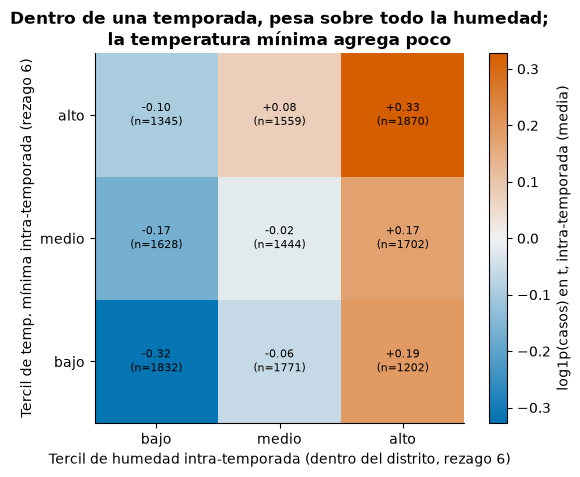

Diferencia intra-temporada alto-alto menos bajo-bajo: 0.646 | sin 2023 y 2024: 0.191 | semana epi mediana (alto-alto, bajo-bajo): [27.0, 25.0]


In [9]:
# Interacción: terciles dentro de distrito de temperatura mínima × humedad en versión INTRA-TEMPORADA (rezago 6)
t_an, h_an = rezagar(d, "temp_min_it", R), rezagar(d, "hum_rel_media_it", R)
ok = t_an.notna() & h_an.notna()
ter = lambda x: x[ok].groupby(d.loc[ok, "ubigeo"]).transform(lambda z: pd.qcut(z.rank(method="first"), 3, labels=["bajo", "medio", "alto"])).astype(str)
base = d.loc[ok].assign(t=ter(t_an), h=ter(h_an))
orden3 = ["bajo", "medio", "alto"]
inter = base.pivot_table(index="t", columns="h", values="l_it", aggfunc="mean").loc[orden3, orden3]
# Sensibilidad: la misma tabla sin las temporadas 2023 y 2024
base_sb = base[~base["temporada"].isin([2023, 2024])]
inter_sb = base_sb.pivot_table(index="t", columns="h", values="l_it", aggfunc="mean").loc[orden3, orden3]
cnt = base.groupby(["t", "h"]).size().unstack().loc[orden3, orden3]
semana_mediana = base.groupby(["t", "h"])["semana"].median().unstack().loc[orden3, orden3]
M["interaccion_tmin_hum_intra_r6_l_it"] = {f"tmin_{t}|hum_{h}": round(float(inter.loc[t, h]), 3) for t in orden3 for h in orden3}
M["interaccion_diferencia_l_it_alto_alto_menos_bajo_bajo"] = round(float(inter.loc["alto", "alto"] - inter.loc["bajo", "bajo"]), 3)
M["interaccion_diferencia_l_it_alto_alto_menos_bajo_bajo_sin_2023_2024"] = round(float(inter_sb.loc["alto", "alto"] - inter_sb.loc["bajo", "bajo"]), 3)
M["interaccion_semana_epi_mediana_alto_alto_y_bajo_bajo"] = [float(semana_mediana.loc["alto", "alto"]), float(semana_mediana.loc["bajo", "bajo"])]

fig, ax = plt.subplots(figsize=(6.3, 4.8))
cmap_d = LinearSegmentedColormap.from_list("d", [COLORES["clima"], "#f2f2f2", COLORES["casos"]])
lim = np.abs(inter.to_numpy()).max()
im = ax.imshow(inter.to_numpy(), cmap=cmap_d, vmin=-lim, vmax=lim, origin="lower")
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{inter.iloc[i, j]:+.2f}\n(n={cnt.iloc[i, j]})", ha="center", va="center", fontsize=8)
ax.set_xticks(range(3), orden3)
ax.set_yticks(range(3), orden3)
ax.grid(False)
ax.set(xlabel=f"Tercil de humedad intra-temporada (dentro del distrito, rezago {R})",
       ylabel=f"Tercil de temp. mínima intra-temporada (rezago {R})",
       title="Dentro de una temporada, pesa sobre todo la humedad;\nla temperatura mínima agrega poco")
fig.colorbar(im, ax=ax, label="log1p(casos) en t, intra-temporada (media)")
guardar_figura(fig, FASE, "05_interaccion_tmin_humedad")
plt.show()
print("Diferencia intra-temporada alto-alto menos bajo-bajo:", M["interaccion_diferencia_l_it_alto_alto_menos_bajo_bajo"],
      "| sin 2023 y 2024:", M["interaccion_diferencia_l_it_alto_alto_menos_bajo_bajo_sin_2023_2024"],
      "| semana epi mediana (alto-alto, bajo-bajo):", M["interaccion_semana_epi_mediana_alto_alto_y_bajo_bajo"])

**Observación** (deciles de la anomalía dentro de cada distrito, rezago 6; tabla arriba):
- En **anomalía** (sin calendario), la anomalía de casos salta en el decil superior de las cuatro variables, incluida la temperatura media. Pero ese decil está formado sobre todo por semanas de las temporadas de brote 2017, 2023 y 2024 (porcentajes arriba). Sin 2023 y 2024 el salto se reduce mucho, y en las temperaturas se invierte (tabla). El salto refleja sobre todo que los **años de brote fueron años anómalamente cálidos o húmedos**, no una relación semana a semana.
- La forma en U de la humedad en valores brutos desaparece con anomalías: era estacional.
- En la versión **intra-temporada** (sin calendario ni año), la **humedad** muestra un gradiente creciente y ordenado a lo largo de los deciles, que se mantiene sin 2023 y 2024. La precipitación muestra una pendiente más irregular. Las temperaturas quedan casi planas, salvo el decil superior con todas las temporadas, que desaparece sin 2023 y 2024 (tabla y figura).
- En la tabla intra-temporada de temperatura mínima × humedad, los casos cambian sobre todo **entre columnas** (humedad) y poco entre filas (temperatura mínima). La diferencia entre las celdas alto-alto y bajo-bajo se reduce mucho sin 2023 y 2024 (cifras arriba). No hay evidencia robusta de una interacción propia.

**Implicación.** Buena parte de la "forma" clima-casos es la diferencia entre años de brote y años tranquilos, que un modelo con historia propia (persistencia) ya captura en parte (sección 4). Dentro de una temporada, la señal utilizable es moderada y viene sobre todo de la humedad (y en menor medida de la precipitación); la interacción con la temperatura mínima no es robusta. Si se usan umbrales (anomalías altas) o la interacción, deben validarse con folds temporales que dejen afuera temporadas de brote, porque de lo contrario el modelo aprendería "año de brote" y no clima.

## 6. Robustez: ¿depende de uno o dos brotes?

**Qué quiero saber:** si las asociaciones de la sección 3 se sostienen al **dejar afuera** cada temporada grande (2017, 2023, 2024), y su incertidumbre con un **bootstrap por bloques de temporada** (1 000 réplicas, semilla 42). Se mide la correlación de Spearman agrupada dentro de cada distrito (mediana) entre la anomalía media de la ventana de rezagos 4-8 y la anomalía de `log1p(casos)`. También se muestra la anomalía climática media de cada temporada, para ver si los años de brote fueron distintos.

In [10]:
for v in VARS:
    d[f"{v}_an_v48"] = sum(rezagar(d, f"{v}_an", r) for r in range(4, 9)) / 5
    d[f"{v}_it_v48"] = sum(rezagar(d, f"{v}_it", r) for r in range(4, 9)) / 5

def rho_mediana(datos, x, y):
    return datos.groupby("ubigeo")[[x, y]].apply(lambda g: g[x].corr(g[y], method="spearman")).median()

rob = {}
for v in VARS:
    fila = {"todas": rho_mediana(d, f"{v}_an_v48", "l_an"),
            "intra_temporada": rho_mediana(d, f"{v}_it_v48", "l_it")}
    for t in [2017, 2023, 2024]:
        fila[f"sin_{t}"] = rho_mediana(d[d["temporada"] != t], f"{v}_an_v48", "l_an")
        fila[f"intra_sin_{t}"] = rho_mediana(d[d["temporada"] != t], f"{v}_it_v48", "l_it")
    boot = bootstrap_bloques(d[["ubigeo", "temporada", f"{v}_an_v48", "l_an"]].dropna(), "temporada",
                             lambda s, v=v: rho_mediana(s, f"{v}_an_v48", "l_an"), n=1000, semilla=42)
    fila["ic95_inf"], fila["ic95_sup"] = np.nanpercentile(boot, [2.5, 97.5])
    rob[v] = fila
rob = pd.DataFrame(rob).T.round(3)
M["robustez_ventana_4_8"] = {v: {k: float(x) for k, x in f.items()} for v, f in rob.iterrows()}
M["variables_ic95_excluye_0"] = [v for v in VARS if rob.loc[v, "ic95_inf"] > 0 or rob.loc[v, "ic95_sup"] < 0]
M["variables_mismo_signo_en_todas_las_versiones"] = [v for v in VARS if (np.sign(rob.loc[v, ["todas", "intra_temporada", "sin_2017", "sin_2023", "sin_2024",
                                                                                                 "intra_sin_2017", "intra_sin_2023", "intra_sin_2024"]]) ==
                                                                       np.sign(rob.loc[v, "todas"])).all() and abs(rob.loc[v, "todas"]) >= 0.05]
print("IC95 % excluye el 0:", M["variables_ic95_excluye_0"])
print("Mismo signo (|rho| ≥ 0.05) en todas las versiones:", M["variables_mismo_signo_en_todas_las_versiones"])
rob

IC95 % excluye el 0: ['precip_total_mm', 'hum_rel_media']
Mismo signo (|rho| ≥ 0.05) en todas las versiones: ['precip_total_mm', 'hum_rel_media', 'viento_max', 'radiacion_total', 'et0_total']


,todas,intra_temporada,sin_2017,intra_sin_2017,sin_2023,intra_sin_2023,sin_2024,intra_sin_2024,ic95_inf,ic95_sup
temp_media,-0.009,-0.017,0.041,0.011,-0.024,-0.135,-0.201,-0.086,-0.365,0.341
temp_max,-0.019,-0.079,0.052,-0.096,-0.035,-0.162,-0.217,-0.159,-0.391,0.287
temp_min,0.168,0.142,0.111,0.146,0.124,-0.035,-0.010,0.059,-0.257,0.496
precip_total_mm,0.273,0.218,0.244,0.182,0.267,0.182,0.314,0.242,0.069,0.509
hum_rel_media,0.285,0.345,0.246,0.330,0.281,0.298,0.352,0.352,0.089,0.551
viento_max,-0.173,-0.244,-0.114,-0.226,-0.150,-0.217,-0.234,-0.255,-0.421,0.025
radiacion_total,-0.158,-0.141,-0.134,-0.165,-0.119,-0.029,-0.190,-0.144,-0.411,0.036
et0_total,-0.152,-0.231,-0.117,-0.228,-0.145,-0.192,-0.267,-0.251,-0.469,0.090


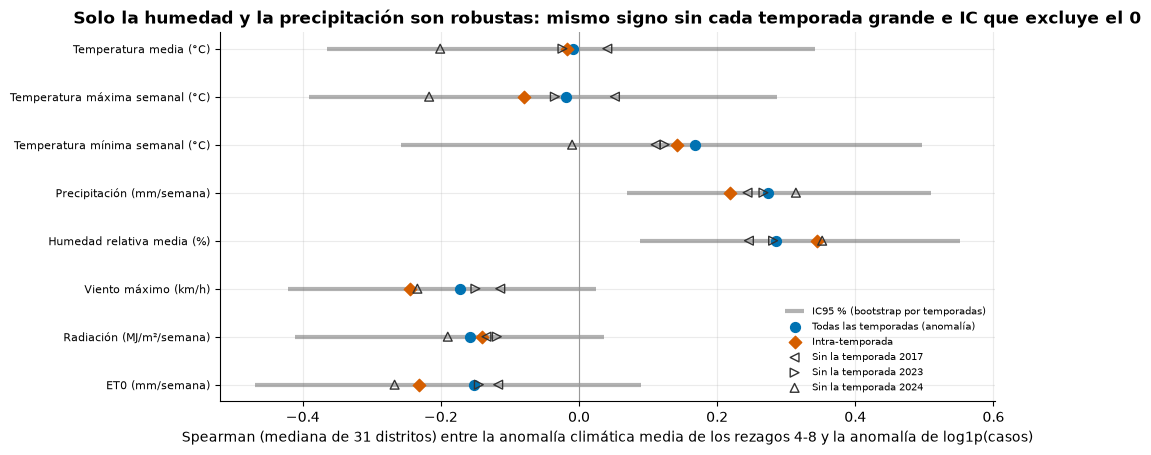

,temp_min_an,precip_total_mm_an,hum_rel_media_an,temp_media_an
temporada,,,,
2017,0.52,28.69,7.42,-0.38
2018,-0.32,-5.42,-0.10,-0.45
2019,0.16,-1.20,1.10,0.06
2020,0.08,-5.90,-2.80,0.37
2021,-0.58,-5.36,-2.28,-0.26
2022,-1.14,-5.17,-1.86,-0.79
2023,0.44,8.84,2.03,0.33
2024,0.79,-3.52,-0.64,0.84
2025,0.20,-0.99,-0.05,0.11


In [11]:
fig, ax = plt.subplots(figsize=(10, 4.8))
y = np.arange(len(VARS))[::-1]
ax.hlines(y, rob["ic95_inf"], rob["ic95_sup"], color=COLORES["referencia"], lw=3, alpha=0.5, label="IC95 % (bootstrap por temporadas)")
ax.scatter(rob["todas"], y, color=COLORES["clima"], s=50, zorder=3, label="Todas las temporadas (anomalía)")
ax.scatter(rob["intra_temporada"], y, color=COLORES["casos"], marker="D", s=40, zorder=3, label="Intra-temporada")
for t, mk in [(2017, "<"), (2023, ">"), (2024, "^")]:
    ax.scatter(rob[f"sin_{t}"], y, facecolor="none", edgecolor="#333333", marker=mk, s=40, zorder=3, label=f"Sin la temporada {t}")
ax.axvline(0, color="#999999", lw=0.8)
ax.set_yticks(y, [ETIQ[v] for v in VARS], fontsize=8)
ax.set(xlabel="Spearman (mediana de 31 distritos) entre la anomalía climática media de los rezagos 4-8 y la anomalía de log1p(casos)",
       title="Solo la humedad y la precipitación son robustas: mismo signo sin cada temporada grande e IC que excluye el 0")
ax.legend(loc="lower right", fontsize=7)
guardar_figura(fig, FASE, "06_robustez")
plt.show()

anom_temp = d.groupby("temporada")[[f"{v}_an" for v in ["temp_min", "precip_total_mm", "hum_rel_media", "temp_media"]]].mean().round(2)
M["anomalia_media_por_temporada"] = {int(t): {k.removesuffix("_an"): float(x) for k, x in f.items()} for t, f in anom_temp.iterrows()}
anom_temp

**Observación.**
- **Humedad y precipitación:** mantienen una asociación positiva al quitar cada temporada grande, en la versión intra-temporada y también intra-temporada sin cada temporada grande, con un intervalo por bootstrap de temporadas que excluye el 0 (listas y tabla arriba).
- **Temperatura mínima:** positiva con todas las temporadas, pero **desaparece sin 2024** (y en la versión intra-temporada, sin 2023), y su intervalo incluye el 0. Depende de una o dos temporadas.
- **Temperatura media y máxima:** no muestran asociación estable; sin 2024 incluso se vuelven negativas.
- **Viento, radiación y ET0:** asociaciones negativas de signo constante, pero con intervalos que incluyen el 0.
- 2017 fue una temporada mucho más lluviosa y húmeda que las demás en los distritos activos, y 2023 también fue más húmeda y lluviosa que el promedio (tabla de anomalías por temporada).

**Cautela:** el intervalo por bootstrap remuestrea solo 10 temporadas (2 incompletas), así que es aproximado. Además, las anomalías usan una climatología calculada con todo el periodo.

**Hipótesis.** Los años de brote coinciden con años anómalamente húmedos y lluviosos (compatible con El Niño costero en 2017; no verificado con datos de este repo). Sin embargo, la asociación también aparece **dentro** de cada temporada, así que no es solo un efecto entre años.
**Implicación.** Es la evidencia más sólida del EDA para incluir **humedad y precipitación** (como anomalías rezagadas en una ventana de 4-8 semanas). La temperatura mínima queda como candidata débil, porque depende de 2024. La confianza es media: las correlaciones son moderadas y su aporte más allá de la persistencia es pequeño (sección 4).

## 7. ¿El clima de las semanas previas distingue a los arranques?

Siguiendo las fases 3 y 4: entre las distrito-semanas candidatas a arranque (sin D1 propio en t − 4 a t − 11, información disponible al predecir), se compara la anomalía climática media de la ventana de rezagos 4-8 entre las que tuvieron D1 en t y las que no. D1 es la marca ilustrativa (tasa ≥ 10 por 100 000 hab.). Como el clima regional y la actividad regional van juntos, la diferencia se calcula **dentro** de estratos de fracción regional de distritos con D1 en t − 4 y se promedia ponderando por el número de arranques. Se usan todos los distritos (no solo los activos), porque los arranques también ocurren fuera de ellos.

Candidatas: 22685; con D1 en t: 490. IC95 % excluye 0: []


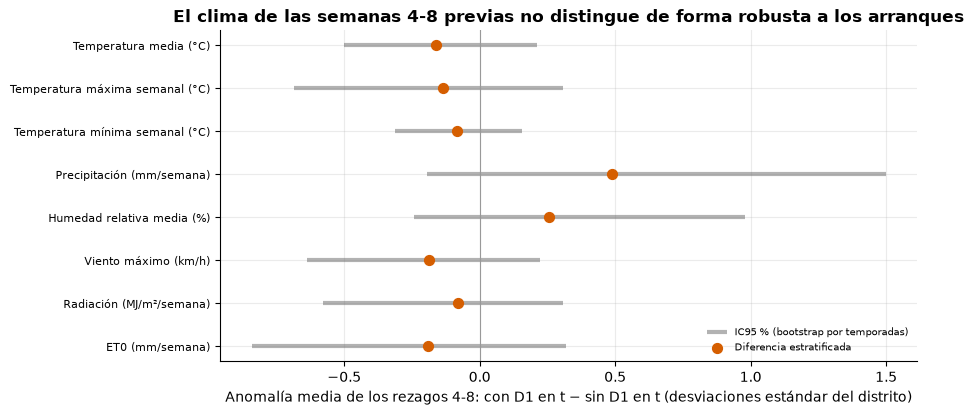

,diferencia_sd,ic95_inf,ic95_sup
temp_media,-0.162,-0.501,0.213
temp_max,-0.137,-0.685,0.307
temp_min,-0.084,-0.313,0.157
precip_total_mm,0.487,-0.194,1.498
hum_rel_media,0.255,-0.242,0.980
viento_max,-0.188,-0.637,0.224
radiacion_total,-0.080,-0.580,0.308
et0_total,-0.191,-0.842,0.317


In [12]:
todo = df.copy()
todo["b"] = brote_umbral_tasa(todo, 10).astype(float)
for v in VARS:
    todo[f"{v}_an"] = anomalia(todo, v)
    todo[f"{v}_an_v48"] = sum(rezagar(todo, f"{v}_an", r) for r in range(4, 9)) / 5
    todo[f"{v}_z"] = todo[f"{v}_an_v48"] / todo.groupby("ubigeo")[f"{v}_an"].transform("std")   # en desviaciones estándar del distrito
frac = todo.groupby("semana_inicio")["b"].transform("mean")
todo["reg4"] = frac.groupby(todo["ubigeo"]).shift(H)
cand = todo[sin_marca_previa(todo, "b", ventana=8, desde_rezago=H) & todo["reg4"].notna()].copy()
cand["estrato"] = pd.cut(cand["reg4"], [-0.001, 0, 0.05, 0.15, 1], labels=["0 %", "0-5 %", "5-15 %", "> 15 %"])
cand["pos"] = cand["b"] == 1

def diferencia_estratificada(c, col):
    difs, pesos = [], []
    for _, g in c.groupby("estrato", observed=True):
        a, b = g.loc[g["pos"], col].dropna(), g.loc[~g["pos"], col].dropna()
        if len(a) >= 5 and len(b) >= 5:
            difs.append(a.mean() - b.mean())
            pesos.append(len(a))
    return float(np.average(difs, weights=pesos)) if pesos else np.nan

dif = {}
for v in VARS:
    fila = {"diferencia_sd": diferencia_estratificada(cand, f"{v}_z")}
    boot = bootstrap_bloques(cand[["temporada", "estrato", "pos", f"{v}_z"]], "temporada",
                             lambda s, v=v: diferencia_estratificada(s, f"{v}_z"), n=1000, semilla=42)
    fila["ic95_inf"], fila["ic95_sup"] = np.nanpercentile(boot, [2.5, 97.5])
    dif[v] = fila
dif = pd.DataFrame(dif).T.round(3)
M["candidatas_arranque_n_y_positivos"] = [int(len(cand)), int(cand["pos"].sum())]
M["arranques_diferencia_anomalia_clima_v48_en_sd"] = {v: {k: float(x) for k, x in f.items()} for v, f in dif.iterrows()}
M["arranques_variables_ic95_excluye_0"] = [v for v in VARS if dif.loc[v, "ic95_inf"] > 0 or dif.loc[v, "ic95_sup"] < 0]
print(f"Candidatas: {M['candidatas_arranque_n_y_positivos'][0]}; con D1 en t: {M['candidatas_arranque_n_y_positivos'][1]}. "
      f"IC95 % excluye 0: {M['arranques_variables_ic95_excluye_0']}")

fig, ax = plt.subplots(figsize=(9, 4.3))
y = np.arange(len(VARS))[::-1]
ax.hlines(y, dif["ic95_inf"], dif["ic95_sup"], color=COLORES["referencia"], lw=3, alpha=0.5, label="IC95 % (bootstrap por temporadas)")
ax.scatter(dif["diferencia_sd"], y, color=COLORES["casos"], s=50, zorder=3, label="Diferencia estratificada")
ax.axvline(0, color="#999999", lw=0.8)
ax.set_yticks(y, [ETIQ[v] for v in VARS], fontsize=8)
ax.set(xlabel="Anomalía media de los rezagos 4-8: con D1 en t − sin D1 en t (desviaciones estándar del distrito)",
       title="El clima de las semanas 4-8 previas no distingue de forma robusta a los arranques")
ax.legend(loc="lower right", fontsize=7)
guardar_figura(fig, FASE, "07_clima_antes_de_arranques")
plt.show()
dif

**Observación.** A igual actividad regional, las candidatas que arrancan venían, en promedio, de semanas previas algo más lluviosas y húmedas (diferencias positivas en precipitación y humedad). Pero **ningún intervalo por bootstrap de temporadas excluye el 0** (tabla): con unos cientos de positivos repartidos en pocas temporadas, la diferencia no es robusta.
**Implicación.** El EDA no encuentra evidencia firme de que el clima rezagado anticipe los arranques más allá de la actividad regional. El dato de los vecinos (fase 4) es un candidato más sólido para ese fin. Si el clima se incluye, su aporte en arranques debe medirse en el modelado y no darse por supuesto.

In [13]:
ruta = guardar_metricas(FASE, M)
print("Métricas guardadas en", ruta.relative_to(ruta.parents[3]))

Métricas guardadas en docs\eda\metricas\fase5_clima.json
